# Read all isotherms from the ISO-DB

In [1]:
import git
import json
import pickle
from tqdm import tqdm
from pathlib import Path

isodb_git_path = Path("isodb-library")

print("Last commit:", git.Repo(isodb_git_path).head.object.hexsha)

Last commit: 4cfcd47e4402f4ff40f893cbbcaa6b86734d8ac6


### Example Isotherm JSON Structure

Each isotherm in the ISODB is stored as a `.json` file. Below is an annotated example
showing the structure from the top-level metadata down to the first data point.

```json
{
    "filename": "10.1002aic.10687.Isotherm2",
    "DOI": "10.1002/aic.10687",
    "articleSource": "Figure 1- CH4 DFT",
    "date": "2018-07-25",
    "digitizer": "Julie Yagodich",
    "adsorbent": {
        "hashkey": "NIST-MATDB-9090fa3691e6b69349dabce8887a8fc8",
        "name": "Carbon Slit Pore"
    },
    "adsorbates": [
        {
            "InChIKey": "VNWKTOKETHGBQD-UHFFFAOYSA-N",
            "name": "Methane"
        }
    ],
    "category": "mod",
    "temperature": 318,
    "tabular_data": 0,
    "isotherm_type": "",
    "adsorptionUnits": "mmol/cm3",
    "pressureUnits": "bar",
    "compositionType": "molefraction",
    "concentrationUnits": "",
    "isotherm_data": [
        {
            "pressure": 129.7,
            "total_adsorption": null,
            "species_data": [
                {
                    "InChIKey": "VNWKTOKETHGBQD-UHFFFAOYSA-N",
                    "composition": 1,
                    "adsorption": 5.7893
                }
            ]
        }
    ]
}
```
This particular isotherm is an example of a modelled one and is not experimental. Additionally we can see the `total_adsorption` given as `null` which is taken care of in the first cleaning process.

In [2]:
# Smart loader: use pickle cache if it exists and matches the current git commit.
# First run after a fresh clone/pull reads all JSON (~14s) and saves the pickle.
# Every subsequent run loads from pickle (~1-2s).

import os, time

pickle_path = Path("data/nistdb.pickle")
commit_file = Path("data/.nistdb_commit")   # tracks which commit the pickle was built from
current_commit = git.Repo(isodb_git_path).head.object.hexsha

# Check if pickle is valid (exists + was built from this commit)
cache_valid = False
if pickle_path.exists() and commit_file.exists():
    stored_commit = commit_file.read_text().strip()
    if stored_commit == current_commit:
        cache_valid = True

if cache_valid:
    t0 = time.perf_counter()
    with open(pickle_path, "rb") as f:
        nistdb = pickle.load(f)
    elapsed = time.perf_counter() - t0
    for key in nistdb:
        print(f"Loaded {len(nistdb[key])} {key}")
    print(f"(from pickle cache in {elapsed:.1f}s)")
else:
    t0 = time.perf_counter()
    nistdb = {
        'Adsorbents': [],
        'Adsorbates': [],
        'Bibliography': [],
        'Isotherms': [],
    }
    for key in nistdb:
        if key == 'Isotherms':
            for iso_path in tqdm((isodb_git_path / "Library").glob("10*/*")):
                with open(iso_path, "r", encoding="utf-8") as iso_json:
                    nistdb[key].append(json.load(iso_json))
        else:
            for json_path in (isodb_git_path / "Library").glob(f"{key}/*"):
                with open(json_path, "r", encoding="utf-8") as json_file:
                    nistdb[key].append(json.load(json_file))
        print(f"Loaded {len(nistdb[key])} {key}")
    elapsed = time.perf_counter() - t0
    print(f"(from JSON in {elapsed:.1f}s)")

    # Save pickle + commit marker for next run
    pickle_path.parent.mkdir(parents=True, exist_ok=True)
    with open(pickle_path, "wb") as f:
        pickle.dump(nistdb, f)
    commit_file.write_text(current_commit)
    print(f"Pickle cache saved for commit {current_commit[:8]}...")

Loaded 9327 Adsorbents
Loaded 455 Adsorbates
Loaded 4647 Bibliography
Loaded 39824 Isotherms
(from pickle cache in 1.5s)


## Cleaning isotherms data
Inspired by 
* Add `total_adsorption`: due to the switch to a multicomponent JSON format, the *total_adsorption* field, which is supposed to show the total amount of all species adsorbed is sometimes left blank. here we iterate and generate this field when it is absent.
* Correct `category=""` when possible: for old data, `category` is left blank. We can correct it only for those isotherm whose biblio is only of one kind. 

In [3]:
# Add total_adsorption
import numpy as np
isos = nistdb['Isotherms']

fixes = 0
for iso in isos:
    if iso['isotherm_data'][0]['total_adsorption'] is None:
        fixes += 1
        for point in iso['isotherm_data']:
            point['total_adsorption'] = float(np.sum([dp['adsorption'] for dp in point['species_data']]))

print(f"Corrections performed in {fixes} isotherms over {len(isos)}.")

Corrections performed in 0 isotherms over 39824.


In [4]:
# Correct category="": assign 'exp' or 'sim' to all isotherms, if the enclosing paper has only one category!

doi_to_category = { bib['DOI'] : bib['categories'] for bib in  nistdb['Bibliography']}

fixes, known, unknown = 0, 0, 0
for iso in isos:
    if iso['category']=="":
        if iso['DOI'] in doi_to_category and len(doi_to_category[iso['DOI']])==1:
            fixes += 1
            iso['category']=doi_to_category[iso['DOI']][0]
        else:
            unknown += 1
    else:
        known +=1
        

print(f"Corrections performed in {fixes} isotherms, {known} already assigned, and {unknown} left unknown.")

Corrections performed in 0 isotherms, 31303 already assigned, and 8521 left unknown.


## Save (or load) pickled isotherms if needed

In [5]:
# Re-save pickle after cleaning (total_adsorption fix + category correction)
# so cached data already includes these corrections on next load
with open(pickle_path, "wb") as f:
    pickle.dump(nistdb, f)
commit_file.write_text(current_commit)
print(f"Pickle cache updated (post-cleaning) for commit {current_commit[:8]}...")

Pickle cache updated (post-cleaning) for commit 4cfcd47e...


In [6]:
# To copy in other notebooks to load the database
print(f"Loaded {len(isos)} full isotherms.")

Loaded 39824 full isotherms.


# Filtering Isotherm to desired criteria

In [7]:
# Displaying total unfiltered isotherms
isos = nistdb['Isotherms']
print(f"Starting isotherms: {len(isos)}")

Starting isotherms: 39824


In [8]:
# Filtering to experimental isotherms
filtered = [isot for isot in isos if isot['category'] == 'exp']
print(f"After experimental filter: {len(filtered)}")

After experimental filter: 25439


In [9]:
# Filtering to methane adsorbates
filtered = [
    isot for isot in filtered
    if len(isot['adsorbates']) == 1
    and isot['adsorbates'][0]['name'] == 'Methane'
]

print(f"After methane filter: {len(filtered)}")

After methane filter: 2525


In [10]:
# Filtering to desired temperature range
temp_min = 273
temp_max = 323

filtered = [isot for isot in filtered if temp_min <= isot['temperature'] <= temp_max]
print(f"After temperature filter ({temp_min}–{temp_max} K): {len(filtered)}")

After temperature filter (273–323 K): 1908


In [11]:
# Removes absorbents with volumetric units - preformed in original script
bad_denominators = {'mol', 'volume', 'cm3', 'm3', 'cm2', 'm2', 'unit cell', 'unitcell', 'formula'}
filtered = [
    isot for isot in filtered
    if not ("/" in isot['adsorptionUnits']
            and isot['adsorptionUnits'].split("/")[-1] in bad_denominators)
]
print(f"After bad denominators filter: {len(filtered)}")

After bad denominators filter: 1806


---

## Unit audit & normalisation

Before applying the uptake filter, confirm what `adsorptionUnits` values remain
after the bad-denominators filter, then convert everything to **mmol/g** so
the uptake bounds are applied on a consistent scale.

In [12]:

# ── Unit audit ───────────────────────────────────────────────────────────────
# Show every unique adsorptionUnits string still present, with an isotherm count.
from collections import Counter

unit_counts = Counter(isot['adsorptionUnits'] for isot in filtered)
non_mmol_g  = {u: c for u, c in unit_counts.items() if u != 'mmol/g'}

print(f"{'Unit':<30}  {'Count':>6}")
print("-" * 42)
for unit, count in sorted(unit_counts.items(), key=lambda x: -x[1]):
    marker = "" if unit == 'mmol/g' else "  ← needs conversion"
    print(f"  {unit:<28}  {count:>6}{marker}")

print(f"\n{len(non_mmol_g)} unit type(s) need conversion, "
      f"covering {sum(non_mmol_g.values())} isotherms.")


Unit                             Count
------------------------------------------
  mmol/g                          1053
  cm3(STP)/g                       509  ← needs conversion
  wt%                              105  ← needs conversion
  mg/g                              56  ← needs conversion
  g/g                               29  ← needs conversion
  ml/g                              26  ← needs conversion
  g/l                               11  ← needs conversion
  mmol/kg                            5  ← needs conversion
                                     3  ← needs conversion
  scf/ton                            3  ← needs conversion
  g/ml                               2  ← needs conversion
  Uptake %                           2  ← needs conversion
  mmol adsorbed                      1  ← needs conversion
  molecules/cage                     1  ← needs conversion

13 unit type(s) need conversion, covering 753 isotherms.


In [13]:
# ── Unit conversion to mmol/g ────────────────────────────────────────────────
# Converts total_adsorption values in-place and updates adsorptionUnits.
# Isotherms with unrecognised units are removed and logged.

M_CH4 = 16.043      # g/mol  (molar mass of methane)
V_STP = 22_414.0    # cm³/mol at STP (0 °C, 1 atm)

def _conversion_factor(unit):
    """
    Returns a multiplier so that:  value_mmol_g = raw_value * factor.
    Returns None if the unit string is unrecognised.
    """
    u = unit.strip().lower()
    u_nospace = u.replace(" ", "")

    if u == 'mmol/g':
        return 1.0                        # already correct

    # mol/kg = 1 mmol/g  (1 mol / 1 kg = 1 mmol / 1 g)
    if u in ('mol/kg',):
        return 1.0

    # mmol/kg → mmol/g
    if u in ('mmol/kg',):
        return 1e-3

    # µmol/g → mmol/g
    if u in ('µmol/g', 'umol/g', 'μmol /g') or u_nospace in ('µmol/g', 'umol/g', 'μmol/g'):
        return 1e-3

    # mg/g → mmol/g  (divide by M_CH4)
    if u in ('mg/g',):
        return 1.0 / M_CH4

    # g/g → mmol/g  (divide by M_CH4 / 1000)
    if u in ('g/g',):
        return 1000.0 / M_CH4

    # g/L → mmol/g (assumes 1 L adsorbent ≈ 1000 g adsorbent bulk)
    if u in ('g/l',):
        return 1.0 / M_CH4

    # g/mL → mmol/g (assumes 1 mL adsorbent ≈ 1 g adsorbent bulk)
    if u in ('g/ml',):
        return 1000.0 / M_CH4

    # cm³(STP)/g, cc(STP)/g, mL(STP)/g, and mL/g (assumed STP) → mmol/g
    if u in ('cm3(stp)/g', 'cc(stp)/g', 'ml(stp)/g',
             'cm3 (stp)/g', 'cc (stp)/g', 'ml (stp)/g', 'ml/g'):
        return 1000.0 / V_STP            # ≈ 0.04461

    # L(STP)/g → mmol/g
    if u in ('l(stp)/g', 'l (stp)/g'):
        return 1000000.0 / V_STP        # ≈ 44.61

    # wt% and uptake% (mass-percent basis) → mmol/g
    if u in ('wt%', 'wt. %', 'wt.%', 'weight %', 'uptake%', 'uptake %'):
        return 10.0 / M_CH4               # = 1000 / 100 / M_CH4

    return None   # unrecognised → isotherm will be dropped


unknown_units   = set()
converted_count = 0
kept            = []

for isot in filtered:
    factor = _conversion_factor(isot['adsorptionUnits'])

    if factor is None:
        unknown_units.add(isot['adsorptionUnits'])
        continue                          # drop; logged below

    if factor != 1.0:
        for pt in isot['isotherm_data']:
            if pt['total_adsorption'] is not None:
                pt['total_adsorption'] *= factor
        isot['adsorptionUnits'] = 'mmol/g'
        converted_count += 1

    kept.append(isot)

filtered = kept

print(f"Converted  : {converted_count} isotherm(s) rescaled to mmol/g")
if unknown_units:
    print(f"Dropped    : isotherms with unrecognised units:")
    for u in sorted(unknown_units):
        print(f"  {u!r}")
else:
    print("Dropped    : 0  (no unrecognised units)")
print(f"Remaining  : {len(filtered)} isotherms - all now in mmol/g")

Converted  : 745 isotherm(s) rescaled to mmol/g
Dropped    : isotherms with unrecognised units:
  ''
  'mmol adsorbed'
  'molecules/cage'
  'scf/ton'
Remaining  : 1798 isotherms - all now in mmol/g


In [14]:
# ── Verification ─────────────────────────────────────────────────────────────
# Confirm every remaining isotherm carries the mmol/g label.
not_mmol_g = [isot for isot in filtered if isot['adsorptionUnits'] != 'mmol/g']
if not_mmol_g:
    print(f"WARNING: {len(not_mmol_g)} isotherm(s) still not in mmol/g:")
    for isot in not_mmol_g:
        print(f"  {isot['adsorbent']['name']!r}  |  {isot['adsorptionUnits']!r}")
else:
    print(f"✓ All {len(filtered)} isotherms confirmed in mmol/g.")

✓ All 1798 isotherms confirmed in mmol/g.


# Removing Non-MOF isotherms

From analysis of the original script, it was found only 12.5% of adsorbents contain the term 'MOF', hence keyword classification is required to flag and remove entires which are clearly not MOFs. As stated in the respective paper, this method is imperfect.

**#1** - Removing non-MOFs based on keywords for non-MOF materials

In [15]:
# ---------- GLOBAL MOF WHITELIST ----------
# These adsorbent names are confirmed MOFs that would otherwise be
# incorrectly removed by one of the downstream filters.
_mof_whitelist = {
    '[La(BTB)(H2O)3DMF]n Activated',      # La-MOF, 'Activated' triggers keyword filter
    '(Me2NH2)2(DMF)9(H2O)5',              # guest-formula MOF, no metal detected by regex
    '2,4,6-tris-(4-carboxyphenoxy)-1,3,5-triazine (H3tcpt)',  # linker-named MOF entry
    'Sc2(O2CC6H4CO2)3',                   # Sc-MOF, carboxylate 'CO2' triggers composite filter
}

# ---------- NON-MOF KEYWORD FILTER (with MOF-rescue) ----------
# Keywords that flag non-MOF materials
non_mof_keywords = ['zeolite', 'carbon', 'graphene', 'graphite', 'silica', 'alumina']

# 'activated' and 'cof' need word-boundary matching to avoid false positives
# e.g. 'MIL-100(Cr), activated at 250C' is a MOF, not activated carbon
# e.g. 'PECONF-1' contains 'cof' substring but is NOT a COF
import re
_boundary_keywords = {
    'activated': re.compile(r'\bactivated\b', re.IGNORECASE),
    'cof':       re.compile(r'\bcof[-\s]?\d*\b', re.IGNORECASE),
}

# MOF family substrings used to RESCUE entries that match a keyword
# If the name also contains one of these, it is still a MOF
_mof_rescue_patterns = [
    'mil-', 'mof-', 'mof(', 'hkust', 'irmof', 'zif-', 'uio', '-mof', 
    'cu-btc', 'cubtc', 'btc', 'pcn-', 'nott-', 'bio-mof',
]

import re
_bracket_formula_mof = re.compile(
    r'^activated\s+[\[\{]|[\]\}]\w*\s+activated',
    re.IGNORECASE
)

def _is_mof_rescue(name_lower):
    if any(pat in name_lower for pat in _mof_rescue_patterns):
        return True
    # NEW: rescue bracket-formula MOF names like "activated [Cu5(BTT)3]n"
    if _bracket_formula_mof.match(name_lower):
        return True
    return False

def not_mof(adsorbent_name, synonyms):
    all_names = [adsorbent_name.lower()] + [s.lower() for s in synonyms]
    for name in all_names:
        # Check plain substring keywords
        if any(kw in name for kw in non_mof_keywords):
            if _is_mof_rescue(name):
                continue
            return True
        # Check boundary keywords
        for kw, pattern in _boundary_keywords.items():
            if pattern.search(name):
                if _is_mof_rescue(name):
                    continue
                return True
    return False

name_to_synonyms = {
    ads['name']: ads['synonyms'] for ads in nistdb['Adsorbents']
}

# Build a quick lookup: adsorbent name -> set of DOIs from isotherms
_name_to_dois = {}
for isot in filtered:
    n = isot['adsorbent']['name']
    _name_to_dois.setdefault(n, set()).add(isot.get('DOI', 'N/A'))

mof_filtered = [
    isot for isot in filtered
    if isot['adsorbent']['name'] in _mof_whitelist
    or not not_mof(
        isot['adsorbent']['name'],
        name_to_synonyms.get(isot['adsorbent']['name'], [])
    )
]

print(f"After non-MOF keyword filter: {len(mof_filtered)}")

After non-MOF keyword filter: 1334


In [16]:
removed_names = sorted(set(
    isot['adsorbent']['name'] for isot in filtered
    if isot['adsorbent']['name'] not in _mof_whitelist
    and not_mof(
        isot['adsorbent']['name'],
        name_to_synonyms.get(isot['adsorbent']['name'], [])
    )
))
print(f"\nRemoved {len(removed_names)} unique adsorbent names as non-MOF:")


Removed 111 unique adsorbent names as non-MOF:


**#2** - Additional filtering step using metal-centre filter
MOFs are defined by metal nodes, if a name/synonym contains a known metal symbol, it is likely a MOF. 

Additionally, well-known MOF families that don't always name their metal explicitly but may be written under common names.

In [17]:
# ---------- METAL-CENTRE / MOF-FAMILY FILTER ----------
import re

metals = [
    # Alkaline earth
    'Mg', 'Ca', 'Sr', 'Ba',
    # Transition metals (3d)
    'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
    # Transition metals (4d)
    'Zr', 'Nb', 'Mo', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd',
    # Transition metals (5d)
    'Hf', 'W', 'Re', 'Ir', 'Pt',
    # Post-transition / metalloids
    'Al', 'Ga', 'In', 'Sn', 'Pb', 'Bi',
    # Lanthanides (commonly found in MOFs)
    'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Y',
]

# Expanded list of institutional / well-known MOF family name prefixes
known_mof_families = [
    # Classic families
    'hkust', 'irmof', 'mof-', 'mof(', 'bio-mof', 'soc-mof',
    'mil-', 'zif-', 'uio-', 'uio(', 'pcn-', 'nott-',
    'mof-5', 'mof-177', 'mof-74', 'mof-399', 'mof-505', 'mof-210', '-mof',
    # Well-known shorthand
    'cubtc', 'cu-btc', 'cu3(btc)',
    # Institutional MOF families
    'nu-',       # Northwestern University
    'utsa',      # University of Texas San Antonio
    'snu-',      # Seoul National University
    'dut-',      # Dresden University of Technology
    'umcm',      # University of Michigan Crystalline Materials
    'cau-',      # Christian-Albrechts-Universitaet (Al-MOFs)
    'cuk-',      # Cork University-Korea
    'fji-',      # Fujian Institute
    'fir-',      # Fujian Institute of Research
    'comoc',     # Centre for Ordered Materials
    'cpm-',      # Crystalline Porous Materials
    'cpf-',      # Crystal Pillar Framework
    'sdu-',      # Shandong University
    'zju-',      # Zhejiang University
    'zjnu',      # Zhejiang Normal University
    'znju',      # Zhejiang Normal (alternate)
    'nju-',      # Nanjing University
    'upc-',      # University of Petroleum China
    'uhm-',      # University of Hamburg
    'maf-',      # Metal Azolate Framework
    'elm-',      # Elastic Layer-structured MOF
    'rod-',      # Rod-based MOF
    'sion-',     # SION (EPFL)
    'hnust',     # Hunan University of Sci. & Tech.
    'ifp-',      # Institut Francais du Petrole MOFs
    'njfu',      # Nanjing Forestry University
    'njtu',      # Nanjing Tech University
    'jlu-',      # Jilin University
    'inof-',     # Indium Organic Framework
    'fmof',      # Fluorinated MOF
    'cid-',      # Coordination Interdigitation
    'peconf',    # PECONF series
    'pku-',      # Peking University
    'nus-',      # National University of Singapore
    'riwmuh',    # CSD refcode (known MOF)
    'xubguy',    # CSD refcode (known MOF)
    'dummop',    # CSD refcode (known MOF)
    'datpim',    # CSD refcode (known MOF)
    'cguc',      # CGUC MOF series
    'basolite',  # Commercial MOFs (BASF)
    'juc-', 'fju-', 'dlsf', 'calf', 'kaust',
    "m'mof",     # M'MOF series
]

def has_metal_or_known_family(name, synonyms):
    all_names_lower = [name.lower()] + [s.lower() for s in synonyms]
    all_names_orig  = [name]         + list(synonyms)

    # Check for known MOF family names (substring on lowercase)
    if any(family in n for family in known_mof_families for n in all_names_lower):
        return True

    # --- Metal detection (two strategies) ---

    # Strategy 1: Case-sensitive check on ORIGINAL names
    # Catches molecular formulas like C10H5MnN3O4, ZnAcBPDC, InOF-1
    for m in metals:
        case_pat = re.compile(
            rf'(?<![A-Za-z]){re.escape(m)}(?=[^a-z]|$)'
        )
        if any(case_pat.search(n) for n in all_names_orig):
            return True

    # Strategy 2: Lowercase word-boundary check (fallback)
    for m in metals:
        pat = re.compile(rf'(?<![a-z]){re.escape(m.lower())}(?![a-z])')
        if any(pat.search(n) for n in all_names_lower):
            return True

    return False

filtered_before_metal = mof_filtered  # snapshot

filtered = [
    iso for iso in mof_filtered
    if iso['adsorbent']['name'] in _mof_whitelist
    or has_metal_or_known_family(
        iso['adsorbent']['name'],
        name_to_synonyms.get(iso['adsorbent']['name'], [])
    )
]
print(f"After metal-centre filter: {len(filtered)}")

# Print what was removed — now with DOIs
removed_by_metal = sorted(set(
    iso['adsorbent']['name'] for iso in filtered_before_metal
    if iso['adsorbent']['name'] not in _mof_whitelist
    and not has_metal_or_known_family(
        iso['adsorbent']['name'],
        name_to_synonyms.get(iso['adsorbent']['name'], [])
    )
))


After metal-centre filter: 1026


**#3** - Composite / non-MOF material exclusion filter

After visual inspection of the remaining dataset, several entries that passed both the keyword and metal-centre filters are clearly not pristine MOF structures. 

In [18]:
# ---------- COMPOSITE / NON-MOF MATERIAL EXCLUSION FILTER ----------
import re

# Remove 'peconf' from the MOF-family rescue list so it no longer gets a free pass
known_mof_families = [f for f in known_mof_families if f != 'peconf']

# --- Plain substring patterns (case-insensitive) ---
_exclude_substrings = [
    '%',               # weight-percent composites
    '@',               # host-guest composites
    'coal',            # coal / shale samples
    'graphite oxide',  # graphite oxide composites
    'peconf',          # porous electron-conducting frameworks
    'zncl2',           # zinc chloride activated carbons
    'tio2',            # titanium dioxide
    'alpo',            # aluminophosphate zeotypes
    'clinoptilolite',  # natural zeolite
    'stress',          # removes degenerate Co(bdp)
    'microwave',       # degenerate cu BDC
    'powder',
    'powdered',        # degenerate cu btc
    'nano', 
    'shaped',
    'sol.ht',   
]

# --- Regex patterns (need word-boundary or positional logic) ---
_exclude_regex = [
    re.compile(r'[-/\s]GO\b'),             # graphene oxide composites (-GO, GO/, " GO")
    re.compile(r'^bio-', re.IGNORECASE),    # Bio-MOF series (start of name only)
    re.compile(r'\bAC\b'),                  # activated carbon (word-boundary, case-sensitive)
    re.compile(r'\bPMO\d*\b'),
    re.compile(r'(?<![A-Za-z])CO2(?![(\d])', re.IGNORECASE)            
]
# --- Exact-match names ---
_exclude_exact = {
    'Cu(I)Y',
    'Cu-MOF',
    'MIL-53(Al)',   
}

def is_excluded_composite(name):
    """Return True if the adsorbent name matches any exclusion pattern."""
    name_lower = name.lower()
    # Exact match
    if name in _exclude_exact:
        return True
    # Substring match 
    if any(pat in name_lower for pat in _exclude_substrings):
        return True
    # Regex match 
    if any(pat.search(name) for pat in _exclude_regex):
        return True
    return False

filtered_before_composite = filtered  # snapshot

filtered = [
    iso for iso in filtered
    if iso['adsorbent']['name'] in _mof_whitelist
    or not is_excluded_composite(iso['adsorbent']['name'])
]
print(f"After composite/non-MOF exclusion filter: {len(filtered)}")

# Print what was removed
removed_by_composite = sorted(set(
    iso['adsorbent']['name'] for iso in filtered_before_composite
    if is_excluded_composite(iso['adsorbent']['name'])
))


After composite/non-MOF exclusion filter: 906


# Filtering Duplicate Isotherms

Duplicate groups found: 133
Isotherms in duplicate groups: 377


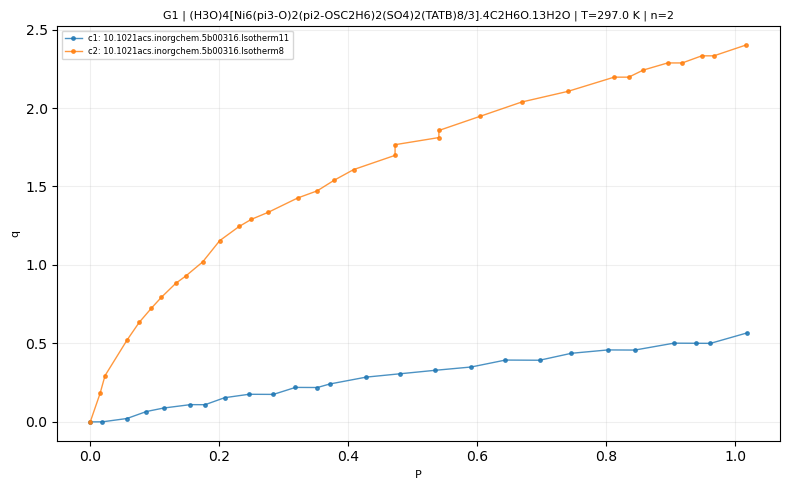

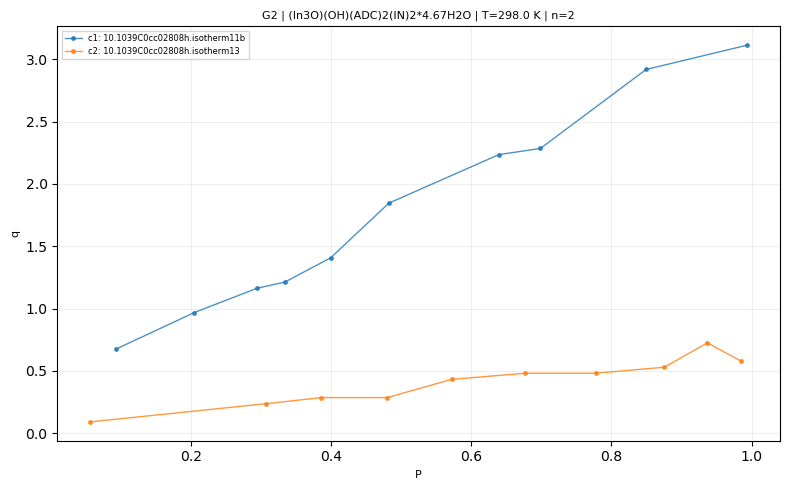

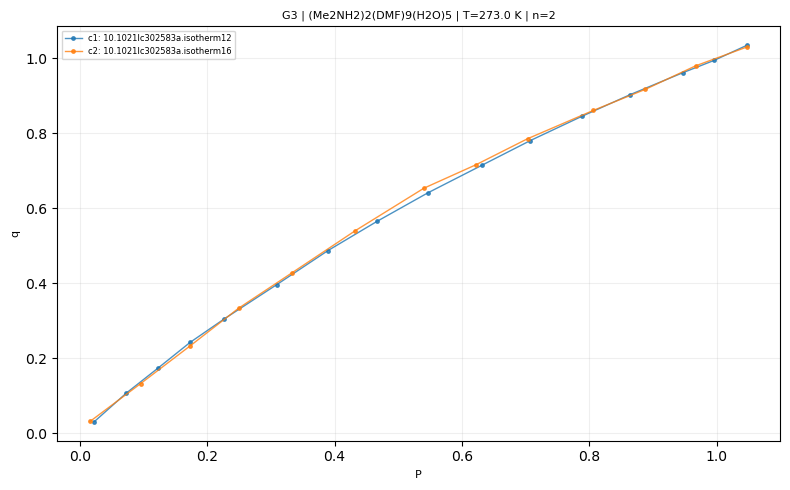

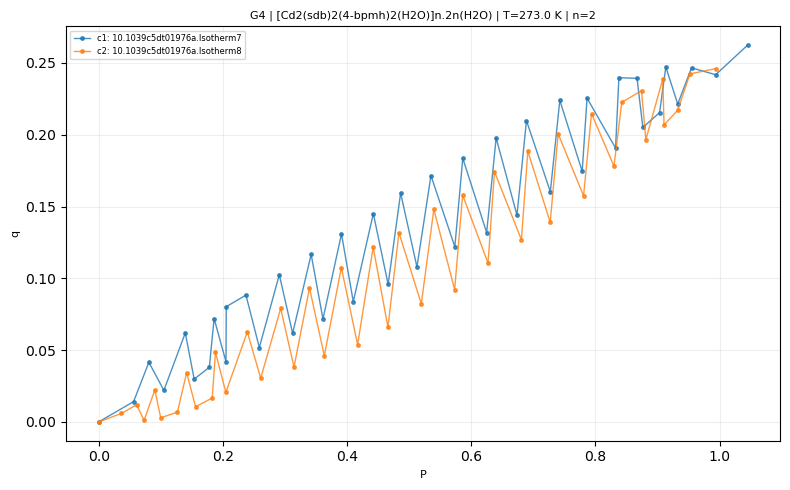

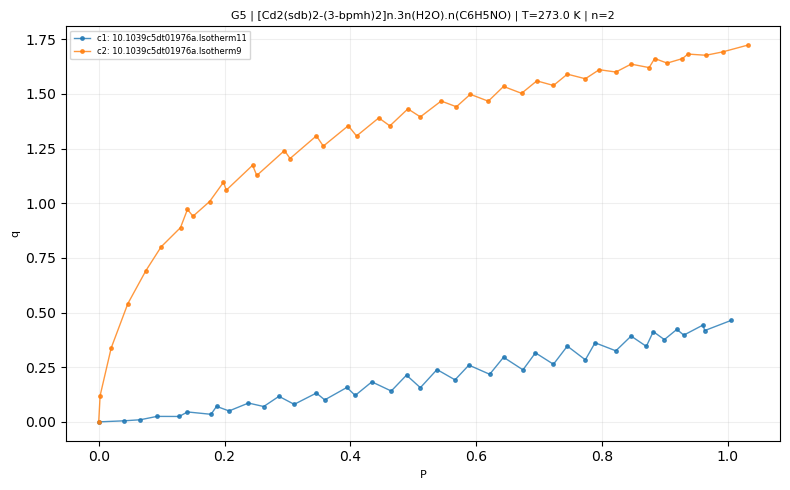

Duplicate-grid export skipped (EXPORT_DUPLICATE_GRID=False).
Whitelist filenames: 146
After duplicate filename selection: 635 isotherms
Duplicate kept: 146 | Duplicate removed: 231


In [19]:
# ---------- DUPLICATE ISOTHERM HANDLING (same hashkey + temperature) ----------
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def _adsorbate_signature(iso):
    return tuple(sorted(a.get("name", "") for a in iso.get("adsorbates", [])))


def _duplicate_key(iso, temp_decimals=3):
    temp = iso.get("temperature", None)
    if temp is not None:
        temp = round(float(temp), temp_decimals)
    return (iso["adsorbent"]["hashkey"], temp, _adsorbate_signature(iso))


def _normalize_filename(name):
    s = str(name).strip()
    if s.lower().endswith(".json"):
        s = s[:-5]
    return s.lower()


def load_keep_filenames(path):
    keep = set()
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.split("#", 1)[0].strip()
        if not line:
            continue
        parts = [p.strip() for p in line.split(",") if p.strip()]
        candidate = parts[-1] if parts else line
        keep.add(_normalize_filename(candidate))
    return keep


def _plot_group_on_axis(ax, group_id, xscale="linear", yscale="linear", show_legend=True):
    key = group_id_to_key[group_id]
    group = duplicate_groups[key]

    for curve_idx, iso in enumerate(group, start=1):
        pts = [
            pt for pt in iso.get("isotherm_data", [])
            if pt.get("pressure") is not None and pt.get("total_adsorption") is not None
        ]
        if not pts:
            continue

        x = [pt["pressure"] for pt in pts]
        y = [pt["total_adsorption"] for pt in pts]
        label = f"c{curve_idx}: {iso.get('filename', 'N/A')}"
        ax.plot(x, y, marker="o", linewidth=1.0, markersize=2.5, alpha=0.8, label=label)

    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_xlabel("P", fontsize=8)
    ax.set_ylabel("q", fontsize=8)
    adsorbent_name = group[0].get("adsorbent", {}).get("name", "N/A")
    ax.set_title(f"G{group_id} | {adsorbent_name} | T={key[1]} K | n={len(group)}", fontsize=8)
    ax.grid(True, alpha=0.2)
    if show_legend:
        ax.legend(fontsize=6, loc="best")


# 1) Group isotherms by duplicate key
all_groups = defaultdict(list)
for iso in filtered:
    all_groups[_duplicate_key(iso)].append(iso)

duplicate_groups = {k: v for k, v in all_groups.items() if len(v) > 1}

def _group_sort_key(k):
    iso0 = duplicate_groups[k][0]
    name = iso0["adsorbent"].get("name", "")
    temp = k[1] if k[1] is not None else float("inf")
    return (name.lower(), temp, k[0])


duplicate_group_keys = sorted(duplicate_groups.keys(), key=_group_sort_key)
group_id_to_key = {i + 1: k for i, k in enumerate(duplicate_group_keys)}

total_groups = len(duplicate_groups)
total_iso_in_groups = sum(len(v) for v in duplicate_groups.values())
print(f"Duplicate groups found: {total_groups}")
print(f"Isotherms in duplicate groups: {total_iso_in_groups}")

# 2) Plot helper 
def plot_duplicate_group(group_id, xscale="linear", yscale="linear"):
    if group_id not in group_id_to_key:
        raise ValueError(f"group_id {group_id} not found. Available: 1..{len(group_id_to_key)}")

    fig, ax = plt.subplots(figsize=(8, 5))
    _plot_group_on_axis(ax, group_id, xscale=xscale, yscale=yscale, show_legend=True)
    plt.tight_layout()
    plt.show()

# Optional quick preview (set lower N for faster rendering in notebook)
N = 5
for gid in list(group_id_to_key.keys())[:N]:
    plot_duplicate_group(gid)


# 3) Optional export: all duplicate-group plots in one high-res image (11 x 12 grid)
EXPORT_DUPLICATE_GRID = False  # set True to enable export (slow, may take ~30s)
EXPORT_GRID_COLS = 11
EXPORT_GRID_ROWS = 12
EXPORT_DPI = 400
EXPORT_PATH = Path("data/duplicate_groups_pairgrid.png")

if EXPORT_DUPLICATE_GRID:
    expected_panels = EXPORT_GRID_ROWS * EXPORT_GRID_COLS
    gids = list(group_id_to_key.keys())[:expected_panels]
    fig, axes = plt.subplots(
        EXPORT_GRID_ROWS,
        EXPORT_GRID_COLS,
        figsize=(EXPORT_GRID_COLS * 3.6, EXPORT_GRID_ROWS * 2.8),
        dpi=EXPORT_DPI,
        constrained_layout=True,
    )
    axes_flat = np.array(axes).reshape(-1)

    for ax, gid in zip(axes_flat, gids):
        _plot_group_on_axis(ax, gid, show_legend=True)

    for ax in axes_flat[len(gids):]:
        ax.axis("off")

    fig.suptitle(
        f"Duplicate Isotherm Groups ({len(gids)} panels, {EXPORT_GRID_COLS}x{EXPORT_GRID_ROWS})",
        fontsize=14,
    )
    EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(EXPORT_PATH, dpi=EXPORT_DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved high-res duplicate grid image -> {EXPORT_PATH}")
    if total_groups != expected_panels:
        print(f"Note: total groups = {total_groups}, grid capacity = {expected_panels}")
else:
    print("Duplicate-grid export skipped (EXPORT_DUPLICATE_GRID=False).")


# 4) Filename whitelist selection for duplicates
keep_file = Path("data/duplicate_keep_filenames.txt")
if not keep_file.exists():
    raise FileNotFoundError(f"Whitelist file not found: {keep_file}")

keep_filename_set = load_keep_filenames(keep_file)

duplicate_filename_records = []
for group_id, key in group_id_to_key.items():
    for iso in duplicate_groups[key]:
        duplicate_filename_records.append({
            "group_id": group_id,
            "filename": iso.get("filename", "N/A"),
            "filename_norm": _normalize_filename(iso.get("filename", "")),
        })

duplicate_filename_df = pd.DataFrame(duplicate_filename_records)
duplicate_filename_norm_set = set(duplicate_filename_df["filename_norm"].tolist()) if len(duplicate_filename_df) else set()

dedup_filtered = []
removed_dup_not_whitelisted = []
for iso in filtered:
    fn = _normalize_filename(iso.get("filename", ""))
    if fn not in duplicate_filename_norm_set or fn in keep_filename_set:
        dedup_filtered.append(iso)
    else:
        removed_dup_not_whitelisted.append(iso.get("filename", "N/A"))

kept_dup = len(keep_filename_set)
dropped_dup = len(duplicate_filename_df) - kept_dup

print(f"Whitelist filenames: {len(keep_filename_set)}")
print(f"After duplicate filename selection: {len(dedup_filtered)} isotherms")
print(f"Duplicate kept: {kept_dup} | Duplicate removed: {dropped_dup}")

# Downstream cells (exports) now use the deduplicated list
filtered = dedup_filtered

# Checking unique isotherms for units consistensy and coherence

- Cell to visually audit remaining isotherms - set 'EXPORT_UNIQUE_PAIRGRID' to True to obtain export

In [26]:
# ---------- VISUAL AUDIT EXPORT FOR REMAINING UNIQUE ISOTHERMS ----------
from math import ceil

# Export controls
EXPORT_UNIQUE_PAIRGRID = True  # set True to enable export of unique isotherms in pairgrid format
UNIQUE_GRID_COLS = 11
UNIQUE_GRID_ROWS = 12
UNIQUE_DPI = 300
UNIQUE_EXPORT_STEM = Path("data/unique_isotherms_pairgrid")

# Per-panel styling
UNIQUE_FIG_W_PER_PANEL = 3.6
UNIQUE_FIG_H_PER_PANEL = 2.8
UNIQUE_TITLE_FONTSIZE = 7
UNIQUE_AXIS_LABEL_FONTSIZE = 7
UNIQUE_TICK_FONTSIZE = 6
UNIQUE_LINEWIDTH = 0.9
UNIQUE_MARKERSIZE = 2.0


def _safe_temp_label(value):
    if value is None:
        return "NA"
    try:
        return f"{float(value):g}"
    except Exception:
        return str(value)


def _plot_single_isotherm_on_axis(ax, iso, show_legend=False):
    pts = [
        pt for pt in iso.get("isotherm_data", [])
        if pt.get("pressure") is not None and pt.get("total_adsorption") is not None
    ]

    if pts:
        x = [pt["pressure"] for pt in pts]
        y = [pt["total_adsorption"] for pt in pts]
        line_label = iso.get("filename", "N/A")
        ax.plot(
            x,
            y,
            marker="o",
            linewidth=UNIQUE_LINEWIDTH,
            markersize=UNIQUE_MARKERSIZE,
            alpha=0.85,
            label=line_label,
        )

    ads_name = iso.get("adsorbent", {}).get("name", "N/A")
    temp_label = _safe_temp_label(iso.get("temperature", None))
    file_label = iso.get("filename", "N/A")

    ax.set_xlabel("P", fontsize=UNIQUE_AXIS_LABEL_FONTSIZE)
    ax.set_ylabel("q", fontsize=UNIQUE_AXIS_LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=UNIQUE_TICK_FONTSIZE)
    ax.set_title(f"{ads_name} | T={temp_label} K\n{file_label}", fontsize=UNIQUE_TITLE_FONTSIZE)
    ax.grid(True, alpha=0.2)

    if show_legend and pts:
        ax.legend(fontsize=6, loc="best")


if EXPORT_UNIQUE_PAIRGRID:
    # Sort for stable visual browsing by material then temperature then filename
    unique_isos = sorted(
        filtered,
        key=lambda iso: (
            iso.get("adsorbent", {}).get("name", "").lower(),
            float(iso.get("temperature", float("inf"))) if iso.get("temperature", None) is not None else float("inf"),
            str(iso.get("filename", "")).lower(),
        ),
    )

    total_isos = len(unique_isos)
    per_page = UNIQUE_GRID_ROWS * UNIQUE_GRID_COLS
    total_pages = ceil(total_isos / per_page) if per_page > 0 else 0

    UNIQUE_EXPORT_STEM.parent.mkdir(parents=True, exist_ok=True)

    print(f"Unique isotherms to export: {total_isos}")
    print(f"Grid: {UNIQUE_GRID_COLS}x{UNIQUE_GRID_ROWS} ({per_page} panels/page)")
    print(f"Pages: {total_pages}")

    for page_idx in range(total_pages):
        start = page_idx * per_page
        end = min(start + per_page, total_isos)
        chunk = unique_isos[start:end]

        fig, axes = plt.subplots(
            UNIQUE_GRID_ROWS,
            UNIQUE_GRID_COLS,
            figsize=(UNIQUE_GRID_COLS * UNIQUE_FIG_W_PER_PANEL, UNIQUE_GRID_ROWS * UNIQUE_FIG_H_PER_PANEL),
            dpi=UNIQUE_DPI,
            constrained_layout=True,
        )

        axes_flat = np.array(axes).reshape(-1)

        for ax, iso in zip(axes_flat, chunk):
            _plot_single_isotherm_on_axis(ax, iso, show_legend=False)

        for ax in axes_flat[len(chunk):]:
            ax.axis("off")

        fig.suptitle(
            f"Unique Isotherms Visual Audit | Page {page_idx + 1}/{total_pages} | Isotherms {start + 1}-{end} of {total_isos}",
            fontsize=14,
        )

        if total_pages == 1:
            out_path = UNIQUE_EXPORT_STEM.with_suffix(".png")
        else:
            out_path = UNIQUE_EXPORT_STEM.parent / f"{UNIQUE_EXPORT_STEM.stem}_p{page_idx + 1:02d}.png"

        fig.savefig(out_path, dpi=UNIQUE_DPI, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved -> {out_path}")
else:
    print("Unique-isotherm pairgrid export skipped (EXPORT_UNIQUE_PAIRGRID=False).")

Unique isotherms to export: 586
Grid: 11x12 (132 panels/page)
Pages: 5
Saved -> data\unique_isotherms_pairgrid_p01.png
Saved -> data\unique_isotherms_pairgrid_p02.png
Saved -> data\unique_isotherms_pairgrid_p03.png
Saved -> data\unique_isotherms_pairgrid_p04.png
Saved -> data\unique_isotherms_pairgrid_p05.png


- Fixing and removing selected isotherms from the audit

In [21]:
# STEP 1/4: Remove isotherms listed in audit_removal_filenames.txt

from pathlib import Path

def _norm_filename(name):
    s = str(name).strip()
    if s.lower().endswith(".json"):
        s = s[:-5]
    return s.lower()

def _load_filename_list(path: Path):
    out = set()
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.split("#", 1)[0].strip()
        if not line:
            continue
        parts = [p.strip() for p in line.split(",") if p.strip()]
        candidate = parts[-1] if parts else line
        out.add(_norm_filename(candidate))
    return out

if "filtered" not in globals():
    raise RuntimeError("Variable 'filtered' is missing. Run the upstream filtering cells first.")

audit_removal_file = Path("data/audit_removal_filenames.txt")
audit_remove_norm = _load_filename_list(audit_removal_file)

removed_count = 0
kept_after_step1 = []
for iso in filtered:
    fn_norm = _norm_filename(iso.get("filename", ""))
    if fn_norm in audit_remove_norm:
        removed_count += 1
        continue
    kept_after_step1.append(iso)

filtered = kept_after_step1

print(f"Step 1 complete | Removed from audit list: {removed_count}")
print(f"Isotherms after step 1: {len(filtered)}")

Step 1 complete | Removed from audit list: 49
Isotherms after step 1: 586


Step 2 complete | Pressure adjusted (100000/14.5038): 6
Isotherms after step 2: 586


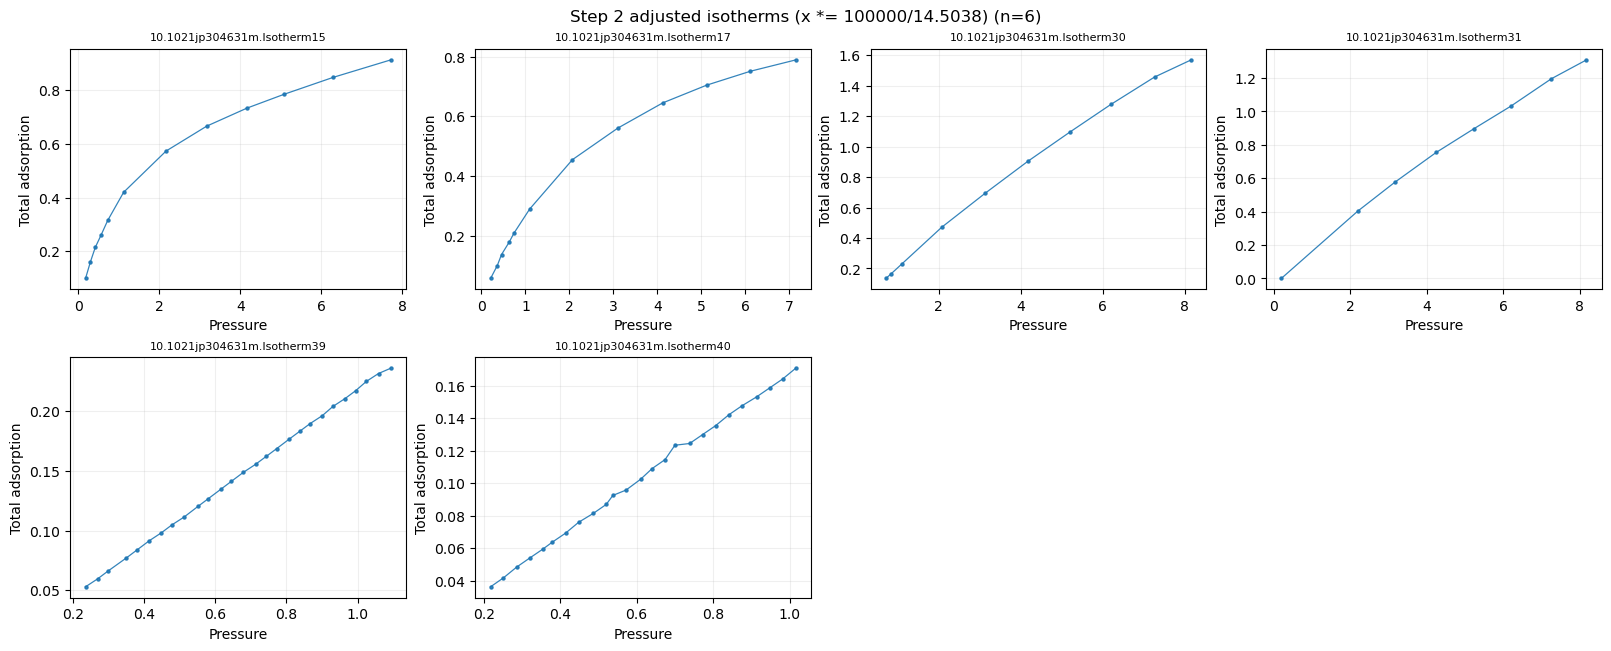

In [22]:
# STEP 2/4: Pressure conversion for selected files (x-axis *= 100000/14.5038) + plot

from math import ceil
import matplotlib.pyplot as plt
import numpy as np

def _norm_filename(name):
    s = str(name).strip()
    if s.lower().endswith(".json"):
        s = s[:-5]
    return s.lower()

def _plot_isotherm_grid(isotherms, title):
    n = len(isotherms)
    if n == 0:
        print(f"{title}: no isotherms to plot.")
        return

    n_cols = 4
    n_rows = ceil(n / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 4.0, n_rows * 3.2),
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = np.array(axes).reshape(-1)

    for ax, iso in zip(axes_flat, isotherms):
        pts = [
            pt for pt in iso.get("isotherm_data", [])
            if pt.get("pressure") is not None and pt.get("total_adsorption") is not None
        ]
        if pts:
            x = [pt["pressure"] for pt in pts]
            y = [pt["total_adsorption"] for pt in pts]
            ax.plot(x, y, marker="o", linewidth=0.9, markersize=2.2, alpha=0.9)
        ax.set_xlabel("Pressure")
        ax.set_ylabel("Total adsorption")
        ax.grid(True, alpha=0.2)
        ax.set_title(str(iso.get("filename", "N/A")), fontsize=8)

    for ax in axes_flat[n:]:
        ax.axis("off")

    fig.suptitle(f"{title} (n={n})", fontsize=12)
    plt.show()

if "filtered" not in globals():
    raise RuntimeError("Variable 'filtered' is missing. Run the upstream filtering cells first.")

psi_to_bar_filenames = {
    "10.1021jp304631m.Isotherm15",
    "10.1021jp304631m.Isotherm17",
    "10.1021jp304631m.Isotherm30",
    "10.1021jp304631m.Isotherm31",
    "10.1021jp304631m.Isotherm39",
    "10.1021jp304631m.Isotherm40",
}
psi_to_bar_norm = {_norm_filename(x) for x in psi_to_bar_filenames}
pressure_factor_psi = 100000.0 / 14.5038

step2_adjusted = []
for iso in filtered:
    fn_norm = _norm_filename(iso.get("filename", ""))
    if fn_norm in psi_to_bar_norm:
        for pt in iso.get("isotherm_data", []):
            p = pt.get("pressure")
            if p is not None:
                pt["pressure"] = p * pressure_factor_psi
        step2_adjusted.append(iso)

step2_count = len(step2_adjusted)
print(f"Step 2 complete | Pressure adjusted (100000/14.5038): {step2_count}")
print(f"Isotherms after step 2: {len(filtered)}")

_plot_isotherm_grid(step2_adjusted, "Step 2 adjusted isotherms (x *= 100000/14.5038)")

Step 3 complete | Adsorption adjusted (1000/22414): 5
Isotherms after step 3: 586


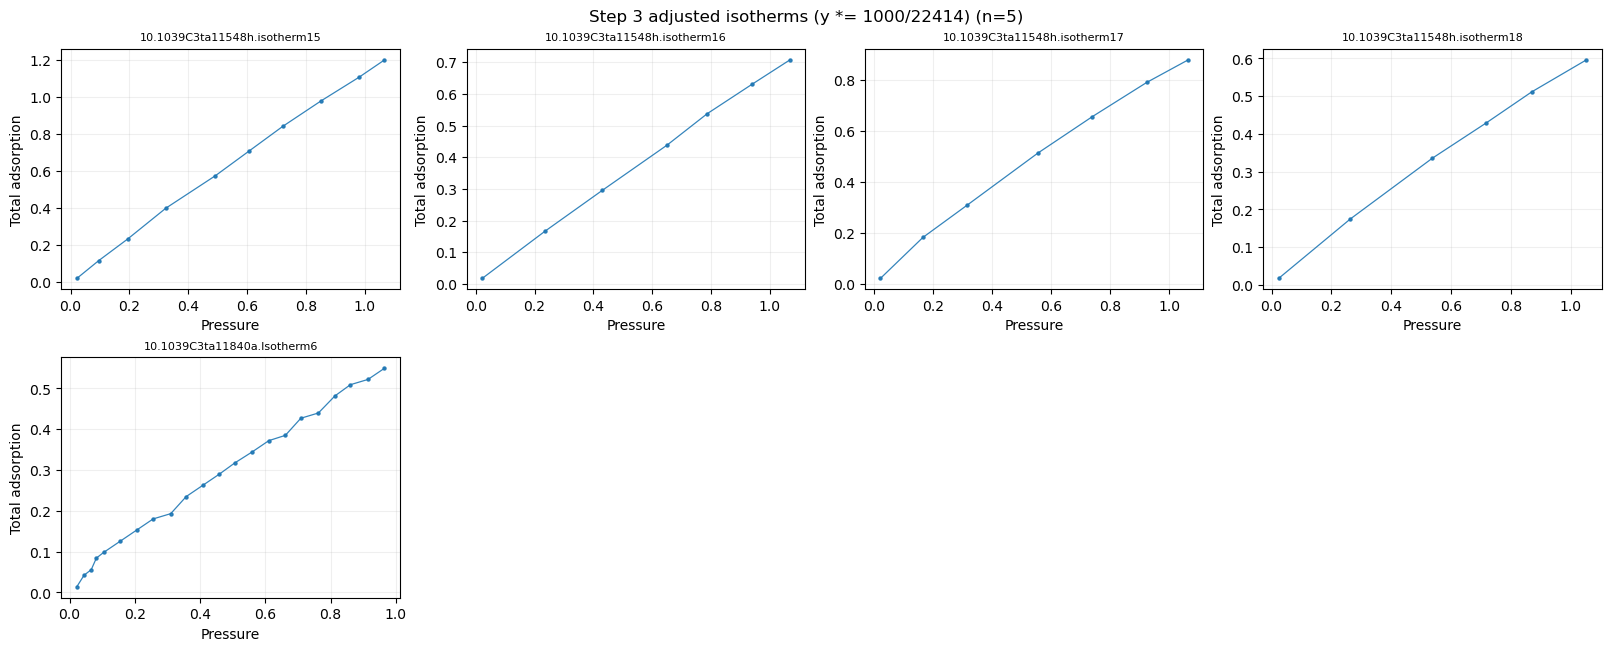

In [23]:
# STEP 3/4: Adsorption conversion for selected files (y-axis *= 1000/22414) + plot

from math import ceil
import matplotlib.pyplot as plt
import numpy as np

def _norm_filename(name):
    s = str(name).strip()
    if s.lower().endswith(".json"):
        s = s[:-5]
    return s.lower()

def _plot_isotherm_grid(isotherms, title):
    n = len(isotherms)
    if n == 0:
        print(f"{title}: no isotherms to plot.")
        return

    n_cols = 4
    n_rows = ceil(n / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 4.0, n_rows * 3.2),
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = np.array(axes).reshape(-1)

    for ax, iso in zip(axes_flat, isotherms):
        pts = [
            pt for pt in iso.get("isotherm_data", [])
            if pt.get("pressure") is not None and pt.get("total_adsorption") is not None
        ]
        if pts:
            x = [pt["pressure"] for pt in pts]
            y = [pt["total_adsorption"] for pt in pts]
            ax.plot(x, y, marker="o", linewidth=0.9, markersize=2.2, alpha=0.9)
        ax.set_xlabel("Pressure")
        ax.set_ylabel("Total adsorption")
        ax.grid(True, alpha=0.2)
        ax.set_title(str(iso.get("filename", "N/A")), fontsize=8)

    for ax in axes_flat[n:]:
        ax.axis("off")

    fig.suptitle(f"{title} (n={n})", fontsize=12)
    plt.show()

if "filtered" not in globals():
    raise RuntimeError("Variable 'filtered' is missing. Run the upstream filtering cells first.")

cm3_to_mmol_filenames = {
    "10.1039C3ta11548h.isotherm17",
    "10.1039C3ta11548h.isotherm18",
    "10.1039C3ta11548h.isotherm15",
    "10.1039C3ta11548h.isotherm16",
    "10.1039C3ta11840a.Isotherm6",
}
cm3_to_mmol_norm = {_norm_filename(x) for x in cm3_to_mmol_filenames}
adsorption_factor = 1000.0 / 22414.0

step3_adjusted = []
for iso in filtered:
    fn_norm = _norm_filename(iso.get("filename", ""))
    if fn_norm in cm3_to_mmol_norm:
        for pt in iso.get("isotherm_data", []):
            q = pt.get("total_adsorption")
            if q is not None:
                pt["total_adsorption"] = q * adsorption_factor
        step3_adjusted.append(iso)

step3_count = len(step3_adjusted)
print(f"Step 3 complete | Adsorption adjusted (1000/22414): {step3_count}")
print(f"Isotherms after step 3: {len(filtered)}")

_plot_isotherm_grid(step3_adjusted, "Step 3 adjusted isotherms (y *= 1000/22414)")

Step 4 complete | Pressure adjusted (1/100): 6
Isotherms after step 4: 586


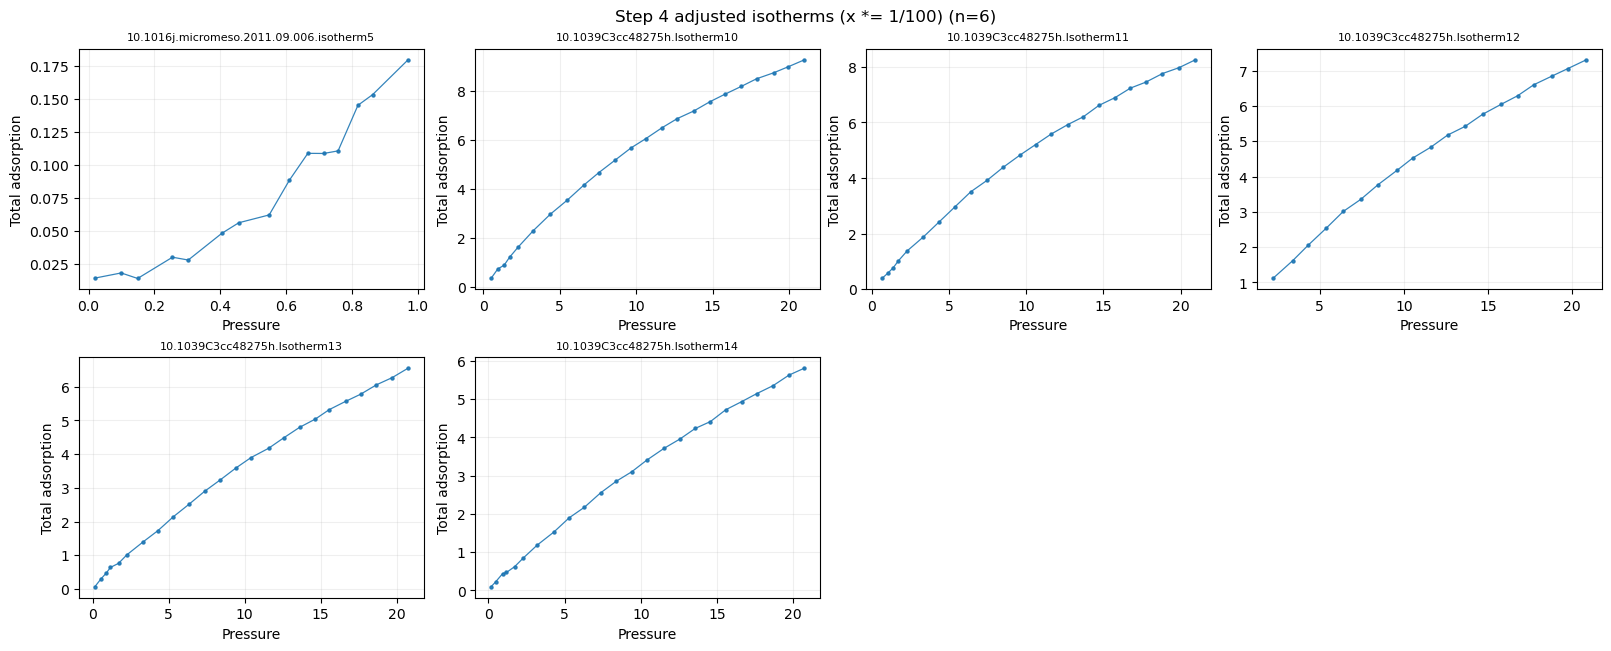

In [24]:
# STEP 4/4: Pressure conversion for selected files (x-axis *= 1/100) + plot

from math import ceil
import matplotlib.pyplot as plt
import numpy as np

def _norm_filename(name):
    s = str(name).strip()
    if s.lower().endswith(".json"):
        s = s[:-5]
    return s.lower()

def _plot_isotherm_grid(isotherms, title):
    n = len(isotherms)
    if n == 0:
        print(f"{title}: no isotherms to plot.")
        return

    n_cols = 4
    n_rows = ceil(n / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 4.0, n_rows * 3.2),
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = np.array(axes).reshape(-1)

    for ax, iso in zip(axes_flat, isotherms):
        pts = [
            pt for pt in iso.get("isotherm_data", [])
            if pt.get("pressure") is not None and pt.get("total_adsorption") is not None
        ]
        if pts:
            x = [pt["pressure"] for pt in pts]
            y = [pt["total_adsorption"] for pt in pts]
            ax.plot(x, y, marker="o", linewidth=0.9, markersize=2.2, alpha=0.9)
        ax.set_xlabel("Pressure")
        ax.set_ylabel("Total adsorption")
        ax.grid(True, alpha=0.2)
        ax.set_title(str(iso.get("filename", "N/A")), fontsize=8)

    for ax in axes_flat[n:]:
        ax.axis("off")

    fig.suptitle(f"{title} (n={n})", fontsize=12)
    plt.show()

if "filtered" not in globals():
    raise RuntimeError("Variable 'filtered' is missing. Run the upstream filtering cells first.")

divide_by_100_filenames = {
    "10.1039C3cc48275h.Isotherm10",
    "10.1039C3cc48275h.Isotherm11",
    "10.1039C3cc48275h.Isotherm12",
    "10.1039C3cc48275h.Isotherm13",
    "10.1039C3cc48275h.Isotherm14",
    "10.1016j.micromeso.2011.09.006.isotherm5",
}
divide_by_100_norm = {_norm_filename(x) for x in divide_by_100_filenames}
pressure_factor_div100 = 1.0 / 100.0

step4_adjusted = []
for iso in filtered:
    fn_norm = _norm_filename(iso.get("filename", ""))
    if fn_norm in divide_by_100_norm:
        for pt in iso.get("isotherm_data", []):
            p = pt.get("pressure")
            if p is not None:
                pt["pressure"] = p * pressure_factor_div100
        step4_adjusted.append(iso)

step4_count = len(step4_adjusted)
print(f"Step 4 complete | Pressure adjusted (1/100): {step4_count}")
print(f"Isotherms after step 4: {len(filtered)}")

_plot_isotherm_grid(step4_adjusted, "Step 4 adjusted isotherms (x *= 1/100)")

To check if our removal of non-MOFs has worked, this cell is used to create a well formatted excel sheet of the removed isotherms with their respective MOFs.

In [25]:

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

wb = Workbook()
wb.remove(wb.active)  # remove default empty sheet

# ── Shared styles ─────────────────────────────────────────────────────────────
_hdr_font   = Font(name="Arial", bold=True, size=11, color="FFFFFF")
_hdr_fill   = PatternFill("solid", fgColor="2F5496")
_hdr_align  = Alignment(horizontal="center", vertical="center")
_thin_side  = Side(style="thin", color="D9D9D9")
_thin_border = Border(left=_thin_side, right=_thin_side,
                      top=_thin_side,  bottom=_thin_side)
_link_font  = Font(name="Arial", size=10, color="0563C1", underline="single")
_body_font  = Font(name="Arial", size=10)
_alt_fill   = PatternFill("solid", fgColor="F2F2F2")

def _write_header(ws, headers, col_widths):
    for col_idx, (h, w) in enumerate(zip(headers, col_widths), 1):
        cell = ws.cell(row=1, column=col_idx, value=h)
        cell.font   = _hdr_font
        cell.fill   = _hdr_fill
        cell.alignment = _hdr_align
        cell.border = _thin_border
        ws.column_dimensions[cell.column_letter].width = w

def _style_row(ws, row_num, n_cols):
    for c in range(1, n_cols + 1):
        ws.cell(row=row_num, column=c).border = _thin_border
        if row_num % 2 == 0:
            ws.cell(row=row_num, column=c).fill = _alt_fill

def _write_doi_cell(ws, row_num, col, doi):
    cell = ws.cell(row=row_num, column=col)
    if doi != "N/A":
        url = f"https://doi.org/{doi}"
        cell.value     = url
        cell.hyperlink = url
        cell.font      = _link_font
    else:
        cell.value = "N/A"
        cell.font  = _body_font

# ── Sheet 1: Keyword filter removals ─────────────────────────────────────────
ws1 = wb.create_sheet("1 - Keyword Filter")
_write_header(ws1, ["#", "Adsorbent Name", "DOI", "DOI Link"], [5, 55, 30, 50])
row_num = 2
for name in removed_names:
    for doi in sorted(_name_to_dois.get(name, {"N/A"})):
        ws1.cell(row=row_num, column=1, value=row_num - 1).font = _body_font
        ws1.cell(row=row_num, column=2, value=name).font         = _body_font
        ws1.cell(row=row_num, column=3, value=doi).font          = _body_font
        _write_doi_cell(ws1, row_num, 4, doi)
        _style_row(ws1, row_num, 4)
        row_num += 1
ws1.auto_filter.ref = f"A1:D{row_num - 1}"
ws1.freeze_panes = "A2"

# ── Sheet 2: Metal-centre filter removals ─────────────────────────────────────
ws2 = wb.create_sheet("2 - Metal-Centre Filter")
_write_header(ws2, ["#", "Adsorbent Name", "DOI", "DOI Link"], [5, 55, 30, 50])
row_num = 2
for name in removed_by_metal:
    for doi in sorted(_name_to_dois.get(name, {"N/A"})):
        ws2.cell(row=row_num, column=1, value=row_num - 1).font = _body_font
        ws2.cell(row=row_num, column=2, value=name).font         = _body_font
        ws2.cell(row=row_num, column=3, value=doi).font          = _body_font
        _write_doi_cell(ws2, row_num, 4, doi)
        _style_row(ws2, row_num, 4)
        row_num += 1
ws2.auto_filter.ref = f"A1:D{row_num - 1}"
ws2.freeze_panes = "A2"


# ── Sheet 3: Composite/non-MOF exclusion removals ────────────────────────────
ws3 = wb.create_sheet("3 - Composite Exclusion")
_write_header(ws3, ["#", "Adsorbent Name", "DOI", "DOI Link"], [5, 55, 30, 50])
row_num = 2
for name in removed_by_composite:
    for doi in sorted(_name_to_dois.get(name, {"N/A"})):
        ws3.cell(row=row_num, column=1, value=row_num - 1).font = _body_font
        ws3.cell(row=row_num, column=2, value=name).font         = _body_font
        ws3.cell(row=row_num, column=3, value=doi).font          = _body_font
        _write_doi_cell(ws3, row_num, 4, doi)
        _style_row(ws3, row_num, 4)
        row_num += 1
ws3.auto_filter.ref = f"A1:D{row_num - 1}"
ws3.freeze_panes = "A2"

# ── Sheet 4: Filtered isotherms (post-all-filters, pre-hashkey dedup) ────────
wb2 = Workbook()
ws4 = wb2.active
ws4.title = "Filtered Isotherms"
_write_header(ws4, ["#", "Adsorbent Name", "Hashkey", "filename", "DOI Link", "Temperature (K)"],
              [5, 55, 38, 30, 50, 16])
row_num = 2
for i, iso in enumerate(sorted(filtered, key=lambda x: x['adsorbent']['name']), start=1):
    name = iso['adsorbent']['name']
    hk   = iso['adsorbent']['hashkey']
    filename  = iso['filename']
    temp = iso.get('temperature', None)
    ws4.cell(row=row_num, column=1, value=i).font    = _body_font
    ws4.cell(row=row_num, column=2, value=name).font = _body_font
    ws4.cell(row=row_num, column=3, value=hk).font   = _body_font
    ws4.cell(row=row_num, column=4, value=filename).font  = _body_font
    _write_doi_cell(ws4, row_num, 5, iso.get('DOI', 'N/A'))
    ws4.cell(row=row_num, column=6, value=temp).font = _body_font
    _style_row(ws4, row_num, 6)
    row_num += 1
ws4.auto_filter.ref = f"A1:F{row_num - 1}"
ws4.freeze_panes = "A2"

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = "data/removed_isotherms_all_filters.xlsx"
wb.save(out_path)
out_path2 = "data/filtered_isotherms.xlsx"
wb2.save(out_path2)
print(f"Saved filtered isotherm inventory → {out_path2}  ({len(filtered)} isotherms)")
print(f"Saved combined removal log → {out_path}")
print(f"  Sheet 1 (Keyword Filter):       {len(removed_names)} adsorbents")
print(f"  Sheet 2 (Metal-Centre Filter):  {len(removed_by_metal)} adsorbents")
print(f"  Sheet 3 (Composite Exclusion):  {len(removed_by_composite)} adsorbents")

PermissionError: [Errno 13] Permission denied: 'data/filtered_isotherms.xlsx'

# MOF SYNONYM DICTIONARY

In [ ]:
# ── MOF SYNONYM DICTIONARY ─────────────────────────────────────────────
# canonical_name → list of dataset names that are the same structure
# Built from Phase 1 (automated) + Sessions 1-3 (web-searched)

_synonym_groups = {
    "MOF-5 / IRMOF-1 / Zn4O(BDC)3":          ["IRMOF-1", "Zn4O", "Zn4O (rho=300kg/m^3)", "Zn4O(BDC)3"],
    "Co21-MOF-5":                              ["Co21-IRMOF-1", "Co21-MOF-5"],
    "HKUST-1 / CuBTC":                         ["Cu-BTC tablet", "Cu-HKUST-1", "CuBTC", "Hydrophilic pore-blocked (CU)3(BTC)2"],
    "MIL-53(Al) / Al-BDC / Basolite A100":     ["Al-BDC", "Basolite A100"],
    "NH2-MIL-53(Al)":                           ["Amino-MIL-53(Al)", "NH2-MIL-53(Al)"],
    "UiO-66 / Zr-BDC":                         ["UiO-66", "Zr-BDC", "Zr-BDC with defect"],
    "UiO-66(Zr)-(COOH)2":                      ["UiO-66(Zr)-(COOH)2 (303K)", "UiO-66(Zr)-(COOH)2 (323K)", "UiO-66(Zr)-(COOH)2 (348K)", "UiO-66(Zr)-(COOH)2 (373K)", "UiO-66(Zr)-(COOH)2 (423K)", "UiO-66(Zr)-(COOH)2 (473K)"],
    "UiO-66-NH2 / Zr-BDC-NH2":                 ["NH2-UiO-66", "UiO-66-NH4", "Zr-BDC-NH2"],  # ⚠ NH4 vs NH2 — review
    "UiO-66-NO2 / Zr-BDC-NO2":                 ["UiO-66-NO2", "Zr-BDC-NO2"],
    "UiO-66-(OH)2":                             ["UiO-66-(OH)2", "opt-UiO-66(Zr)-(OH)2"],
    "UiO-67 / Zr-BPDC":                        ["UiO-67", "Zr-BPDC"],
    "Zn-MOF-74 / MOF-74":                      ["MOF-74", "Zn-MOF-74"],
    "Mg-MOF-74 / Mg2(dobdc)":                  ["Mg-MOF-74", "Mg-MOF-74 (3)", "Mg-MOF-74 (4)", "Mg2(dobdc)"],
    "Ni-MOF-74 / Ni2(dobdc)":                  ["MOF-74-Ni", "Ni-MOF-74 (1)", "Ni-MOF-74 (2)", "Ni2(dobdc)"],
    "Co-MOF-74":                                ["Co100-MOF-74", "MOF-74-Co"],
    "Fe-MOF-74 / Fe2(dobdc)":                   ["Fe2(O2)(dobdc)", "Fe2(dobdc)"],
    "MIL-100(Cr)":                              ["MIL-100", "MIL-100(Cr)", "MIL-100(Cr), activated at 150C", "MIL-100(Cr), activated at 250C"],  # ⚠ MIL-100 assumed Cr
    "MIL-100(V)":                               ["MIL-100(V)", "MIL-100V after O2 binding", "MIL-100V before O2 binding"],
    "MIL-101(Cr)":                              ["Cr-MIL(101)", "MIL-101", "MIL-101FF(Cr)"],
    "MIL-101(V)":                               ["MIL-101V after O2 binding", "MIL-101V before O2 binding"],
    "Zn-DABCO / DMOF-1":                        ["Zn(BDC)(DABCO)0.5", "Zn(bdc)(ted)0.5", "Zn-DABCO"],
    "SDU-1 / Cu-SDU-1":                         ["Cu-SDU-1", "SDU-1"],
    "WV-1050":                                  ["WV-1050", "WV1050"],
    "[Ni3(HCOO)6]":                             ["Ni3(HCOO)6", "[Ni3(HCOO)6]"],
    "Zn3(TCPB)2":                               ["Zn3(TCPB)2(H2O)2", "[Zn3(TCPB)2*2H2O]*2H2O*4DMF"],
    "Zr-FUM":                                   ["Zr-FUM", "Zr-fum MOF (393 k)"],
    "MOF-505 / NOTT-100a":                      ["MOF-505", "NOTT-100a"],
    "ELM-11 / Cu(BF4)2(bpy)2":                  ["ELM-11", "Cu(BF4)2(bpy)2"],
    "ZIF-8 / NZIF-8":                           ["ZIF-8", "NZIF-8"],  # ⚠ NZIF-8 = nano-ZIF-8
    "MOF-508 / Zn(BDC)(BPY) 0.5":              ["MOF-508", "MOF-508b", "Zn(BDC)(BPY) 0.5"],
}

# Build reverse lookup: name → canonical group name
_name_to_synonym_group = {}
for canonical, members in _synonym_groups.items():
    for m in members:
        _name_to_synonym_group[m] = canonical

# Helper: get all synonyms for a name (excluding itself)
def get_synonyms(name):
    group = _name_to_synonym_group.get(name)
    if group is None:
        return []
    return [m for m in _synonym_groups[group] if m != name]

# Stats
n_groups = len(_synonym_groups)
n_names = len(_name_to_synonym_group)
print(f"Synonym dictionary: {n_groups} groups, {n_names} names covered")
print(f"Example: get_synonyms('IRMOF-1') → {get_synonyms('IRMOF-1')}")
print(f"Example: get_synonyms('ELM-11')  → {get_synonyms('ELM-11')}")


Synonym dictionary: 30 groups, 80 names covered
Example: get_synonyms('IRMOF-1') → ['Zn4O', 'Zn4O (rho=300kg/m^3)', 'Zn4O(BDC)3']
Example: get_synonyms('ELM-11')  → ['Cu(BF4)2(bpy)2']


# Exporting the filtered database

In [ ]:
# Collect unique adsorbent HASHKEYS from the filtered isotherms
from collections import defaultdict
unique_adsorbent_hashkeys = set(isot['adsorbent']['hashkey'] for isot in filtered) 

hashkey_to_temps = defaultdict(set)
for iso in filtered:
    hashkey_to_temps[iso['adsorbent']['hashkey']].add(iso['temperature'])

output_records = []
for ads in nistdb['Adsorbents']:
    if ads['hashkey'] in unique_adsorbent_hashkeys:
        all_dois = sorted(_name_to_dois.get(ads['name'], {'N/A'}))
        representative_doi = all_dois[0]
        temps = sorted(hashkey_to_temps.get(ads['hashkey'], set()))
        output_records.append({
            'name': ads['name'],
            'hashkey': ads['hashkey'],
            'DOI': representative_doi,
            'DOIs': all_dois,
            'Temperatures': temps,
            'synonyms': ads['synonyms'],
        })

print(f"Number of unique adsorbents: {len(output_records)}")

Number of unique adsorbents: 423


In [ ]:
# How many adsorbents actually have synonyms?
has_syns = sum(1 for ads in nistdb['Adsorbents'] 
               if ads['hashkey'] in unique_adsorbent_hashkeys 
               and len(ads['synonyms']) > 0)
print(f"{has_syns} / {len(unique_adsorbent_hashkeys)} adsorbents have ≥1 synonym")

26 / 423 adsorbents have ≥1 synonym


In [ ]:
# Save JSON for CIF matching
with open('data/mof_adsorbents_for_cif_matching.json', 'w', encoding='utf-8') as f:
    json.dump(output_records, f, indent=2, ensure_ascii=False)

# Excel export — matched style of removal log sheets
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

wb = Workbook()
ws = wb.active
ws.title = "Filtered MOF Adsorbents"

_hdr_font   = Font(name="Arial", bold=True, size=11, color="FFFFFF")
_hdr_fill   = PatternFill("solid", fgColor="2F5496")
_hdr_align  = Alignment(horizontal="center", vertical="center")
_thin_side  = Side(style="thin", color="D9D9D9")
_thin_border = Border(left=_thin_side, right=_thin_side,
                      top=_thin_side,  bottom=_thin_side)
_body_font  = Font(name="Arial", size=10)
_alt_fill   = PatternFill("solid", fgColor="F2F2F2")

headers    = ["#", "Adsorbent Name", "Hashkey", "DOI", "DOI Link"]
col_widths = [5, 45, 38, 30, 50]
for col_idx, (h, w) in enumerate(zip(headers, col_widths), 1):
    cell = ws.cell(row=1, column=col_idx, value=h)
    cell.font      = _hdr_font
    cell.fill      = _hdr_fill
    cell.alignment = _hdr_align
    cell.border    = _thin_border
    ws.column_dimensions[cell.column_letter].width = w

_link_font = Font(name="Arial", size=10, color="0563C1", underline="single")

for i, rec in enumerate(sorted(output_records, key=lambda r: r['name']), start=1):
    dois = sorted(_name_to_dois.get(rec['name'], {"N/A"}))
    for doi in dois:
        row_num = i + 1
        ws.cell(row=row_num, column=1, value=i).font          = _body_font
        ws.cell(row=row_num, column=2, value=rec['name']).font = _body_font
        ws.cell(row=row_num, column=3, value=rec['hashkey']).font = _body_font
        ws.cell(row=row_num, column=4, value=doi).font         = _body_font
        link_cell = ws.cell(row=row_num, column=5)
        if doi != "N/A":
            url = f"https://doi.org/{doi}"
            link_cell.value     = url
            link_cell.hyperlink = url
            link_cell.font      = _link_font
        else:
            link_cell.value = "N/A"
            link_cell.font  = _body_font
        for c in range(1, 6):
            ws.cell(row=row_num, column=c).border = _thin_border
            if row_num % 2 == 0:
                ws.cell(row=row_num, column=c).fill = _alt_fill
        i += 1

ws.auto_filter.ref = f"A1:E{row_num}"
ws.freeze_panes = "A2"
wb.save("data/filtered_mof_adsorbents.xlsx")

print(f"Exported {len(output_records)} unique MOF adsorbents")
print(f"  → data/mof_adsorbents_for_cif_matching.json")
print(f"  → data/mof_adsorbent_names.txt")
print(f"  → data/filtered_mof_adsorbents.xlsx")

Exported 423 unique MOF adsorbents
  → data/mof_adsorbents_for_cif_matching.json
  → data/mof_adsorbent_names.txt
  → data/filtered_mof_adsorbents.xlsx
